# **Evaluation Notebook**

### **Wikiart Project**

**Group x:**\
**Afonso Hermenegildo** - 202 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 2022

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. [Classification report (accuracy, macro-F1, per-class precision/recall)](#section-1)  
2. [Confusion matrix (seaborn heatmap)](#section-2)  
3. [Training curves (loss & accuracy)](#section-3)  
4. [Grad-CAM visualisation](#section-4)  
5. [Misclassified samples analysis](#section-5)
6. [Model comparison table](#section-5)

---

# Imports

In [10]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

import keras
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory
from notebooks.baseline_model import BaselineModel

# Paths — adjust if needed
DATA_DIR    = Path('Data')
OUTPUTS_DIR = Path('outputs')
FIGURES_DIR = OUTPUTS_DIR / 'figures'
MODULES_DIR  = OUTPUTS_DIR / 'modules'
NOTEBOOK_DIR = Path('notebooks')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 32
SEED        = 42

# Load dataset

In [11]:
train_df = image_dataset_from_directory(
    DATA_DIR / "Train",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_df = image_dataset_from_directory(
    DATA_DIR / "Validation",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_df = image_dataset_from_directory(
    DATA_DIR / "Test",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

class_names = train_df.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 9329 files belonging to 23 classes.
Found 1999 files belonging to 23 classes.
Found 2000 files belonging to 23 classes.
Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


Because we've done our one subclassed model, model.build() often fails to statically infer shapes through complex internal layers like data augmentation. 
By running a dummy image through the network instead, we force a real forward pass that guarantees every layer dynamically initializes its weights based on the actual tensor size.

In [12]:
# Load the best checkpoint saved during training
# Update the path to match whichever model you want to evaluate
model = BaselineModel()
model.build((None, 128, 128, 3))

# 2. Create a "dummy" image (Batch size 1, 128x128 pixels, 3 color channels)
# We fill it with zeros so it processes instantly
dummy_image = tf.zeros((1, 128, 128, 3))

# 3. FORCE the model to build by doing a quick prediction
# We don't care about the output, we just need the data to flow through
_ = model(dummy_image)

model_path = MODULES_DIR / "baseline_cnn.keras/model.weights.h5"
model.load_weights(model_path)

print(f'Model loaded from: {model_path}')
model.summary()

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'baseline_model_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model loaded from: outputs\modules\baseline_cnn.keras\model.weights.h5


Model: "baseline_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_moderate_noise     │ ?                      │   0 (unbuilt) │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (1, 128, 128, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (1, 126, 126, 128)     │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 124, 124, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 60, 60, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (1, 58, 58, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (1, 27, 27, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (1, 25, 25, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (1, 10, 10, 512)       │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (1, 8, 8, 512)         │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 23)                │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,768,343 (22.00 MB)

 Trainable params: 5,768,343 (22.00 MB)

 Non-trainable params: 0 (0.00 B)

# Make Predictions

In [13]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_df:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

accuracy = np.mean(y_true == y_pred)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.5810


# Classification Report

## 4. Classification report
> Primary metric for this project is **macro-F1** because classes may be imbalanced.
> Macro-F1 gives equal weight to all classes regardless of size.
> If macro-F1 is much lower than accuracy, the model is biased toward majority classes.

In [14]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.63      0.61      0.62        87
      Boris_Kustodiev       0.59      0.51      0.54        67
     Camille_Pissarro       0.45      0.44      0.45        93
        Childe_Hassam       0.62      0.18      0.27        57
         Claude_Monet       0.46      0.76      0.57       140
          Edgar_Degas       0.44      0.36      0.40        64
        Eugene_Boudin       0.85      0.59      0.69        58
         Gustave_Dore       0.71      0.86      0.78        80
           Ilya_Repin       0.65      0.43      0.52        56
      Ivan_Aivazovsky       0.69      0.85      0.76        60
        Ivan_Shishkin       0.69      0.54      0.60        54
  John_Singer_Sargent       0.64      0.60      0.62        83
         Marc_Chagall       0.57      0.37      0.45        81
      Martiros_Saryan       0.27      0.23      0.25        61
     Nicholas_Roerich       0.67      0.72      0.69  

## 5. Confusion matrix
> The diagonal = correct predictions. Off-diagonal = errors.
> Look for clusters of errors between visually similar classes.

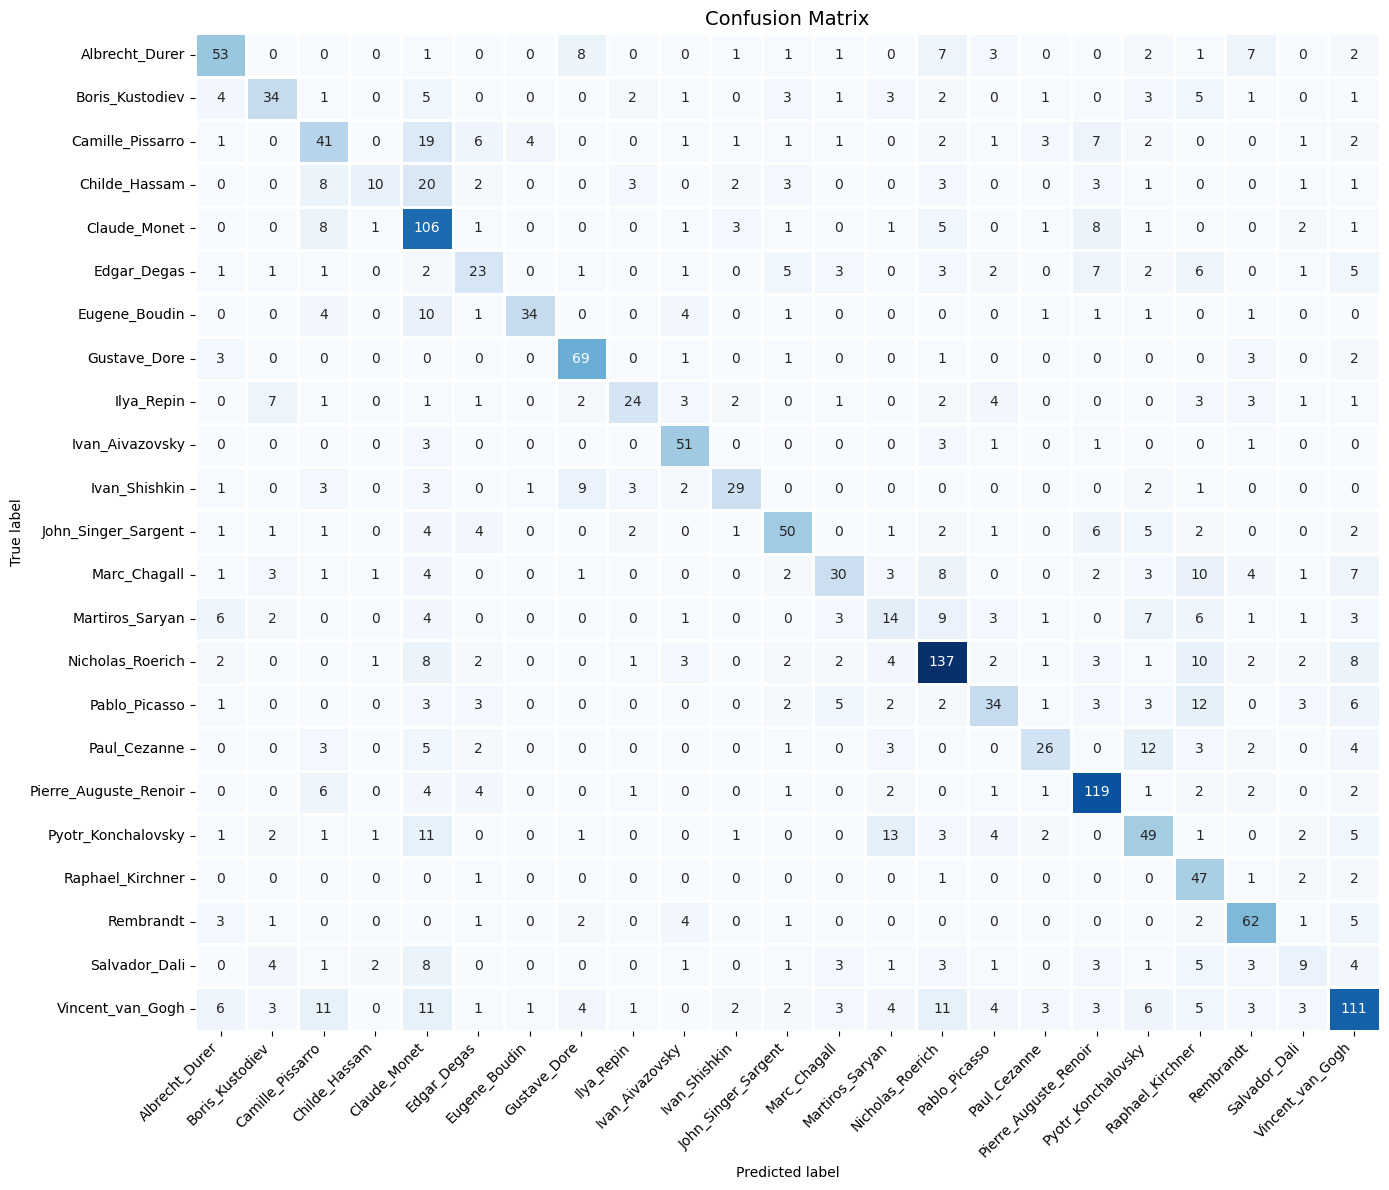


Per-class accuracy:
  Albrecht_Durer                 0.609
  Boris_Kustodiev                0.507
  Camille_Pissarro               0.441
  Childe_Hassam                  0.175
  Claude_Monet                   0.757
  Edgar_Degas                    0.359
  Eugene_Boudin                  0.586
  Gustave_Dore                   0.863
  Ilya_Repin                     0.429
  Ivan_Aivazovsky                0.850
  Ivan_Shishkin                  0.537
  John_Singer_Sargent            0.602
  Marc_Chagall                   0.370
  Martiros_Saryan                0.230
  Nicholas_Roerich               0.717
  Pablo_Picasso                  0.425
  Paul_Cezanne                   0.426
  Pierre_Auguste_Renoir          0.815
  Pyotr_Konchalovsky             0.505
  Raphael_Kirchner               0.870
  Rembrandt                      0.756
  Salvador_Dali                  0.180
  Vincent_van_Gogh               0.561


In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 7. Grad-CAM
> Visualises which regions of the painting the model focuses on.
> Reference: https://keras.io/examples/vision/grad_cam/
> For VGG16, the last conv layer is `block5_conv3`.

In [19]:
# 1. Warm-up: Run a real pass so Keras tracks the connections
# We use one batch from your test set
for images, labels in test_df.take(1):
    _ = model(images) 

# 2. Now the layers have "outputs", we can define the Grad-CAM model
# Get the layer by name (adjusting to your summary: conv2d_15)
target_layer_name = 'conv2d_15'
target_layer = model.get_layer(target_layer_name)

# 3. Build the visualization model
# This connects the main model input to the specific conv layer output
grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[target_layer.output, model.output]
)

# 4. Grad-CAM calculation function
def get_heatmap(img_batch, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        # Find the index of the predicted class
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Calculate gradients of the class relative to the feature map
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the gradients
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

# 5. Execute and Display
for images, labels in test_df.take(1):
    img_np = images[0].numpy().astype('uint8')
    img_batch = tf.expand_dims(images[0], axis=0)
    
    heatmap, pred_idx = get_heatmap(img_batch, grad_model)
    
    # Resize and overlay
    heatmap_res = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    # 0.6 original image + 0.4 heatmap
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"True Style: {class_names[np.argmax(labels[0])]}")
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Prediction: {class_names[pred_idx]}")
    plt.show()

AttributeError: The layer conv2d_15 has never been called and thus has no defined output.

## 8. Misclassified samples
> Show the worst predictions — highest confidence but wrong.
> Ask: are these images ambiguous? Similar to another class? Possibly mislabelled?

Total misclassified: 838 / 2000 (41.9%)


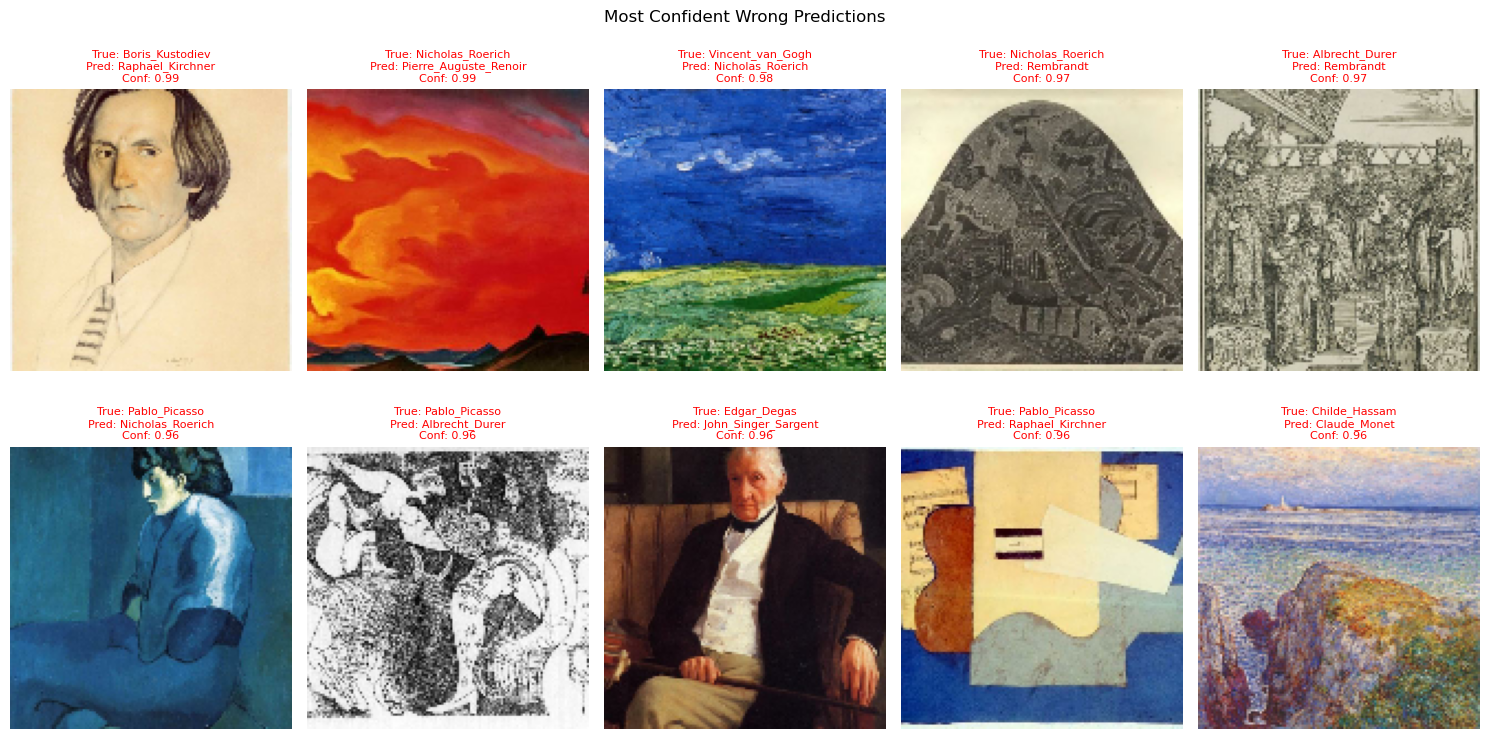

In [20]:
# Collect all misclassified images with their confidence
wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_df:
    probs        = model.predict(images, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            wrong_imgs.append(images[i].numpy().astype('uint8'))
            wrong_true.append(true_classes[i])
            wrong_pred.append(pred_classes[i])
            wrong_conf.append(probs[i][pred_classes[i]])   # confidence of wrong prediction

# Sort by highest confidence wrong prediction (worst mistakes)
sorted_idx  = np.argsort(wrong_conf)[::-1]
n_show      = min(10, len(sorted_idx))

print(f'Total misclassified: {len(wrong_imgs)} / {len(y_true)} ({len(wrong_imgs)/len(y_true)*100:.1f}%)')

cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, idx in enumerate(sorted_idx[:n_show]):
    axes[i].imshow(wrong_imgs[idx])
    axes[i].set_title(
        f'True: {class_names[wrong_true[idx]]}\nPred: {class_names[wrong_pred[idx]]}\nConf: {wrong_conf[idx]:.2f}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Most Confident Wrong Predictions', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'misclassified.png', dpi=150)
plt.show()

In [ ]:
print(f"{'Class Name':<30} | {'Total Errors'}")
print("-" * 45)

for i, name in enumerate(class_names):
    # Total images in this class minus the ones on the diagonal (correct)
    total_in_class = cm[i].sum()
    correct_preds = cm[i, i]
    errors = total_in_class - correct_preds
    
    print(f"{name:<30} | {int(errors)}")

Class Name                     | Total Errors
---------------------------------------------
Albrecht_Durer                 | 34
Boris_Kustodiev                | 33
Camille_Pissarro               | 52
Childe_Hassam                  | 47
Claude_Monet                   | 34
Edgar_Degas                    | 41
Eugene_Boudin                  | 24
Gustave_Dore                   | 11
Ilya_Repin                     | 32
Ivan_Aivazovsky                | 9
Ivan_Shishkin                  | 25
John_Singer_Sargent            | 33
Marc_Chagall                   | 51
Martiros_Saryan                | 47
Nicholas_Roerich               | 54
Pablo_Picasso                  | 46
Paul_Cezanne                   | 35
Pierre_Auguste_Renoir          | 27
Pyotr_Konchalovsky             | 48
Raphael_Kirchner               | 7
Rembrandt                      | 20
Salvador_Dali                  | 41
Vincent_van_Gogh               | 87


C:\Users\marco\AppData\Local\Temp\ipykernel_20376\2631813704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts, y=class_names, palette='Reds_r')


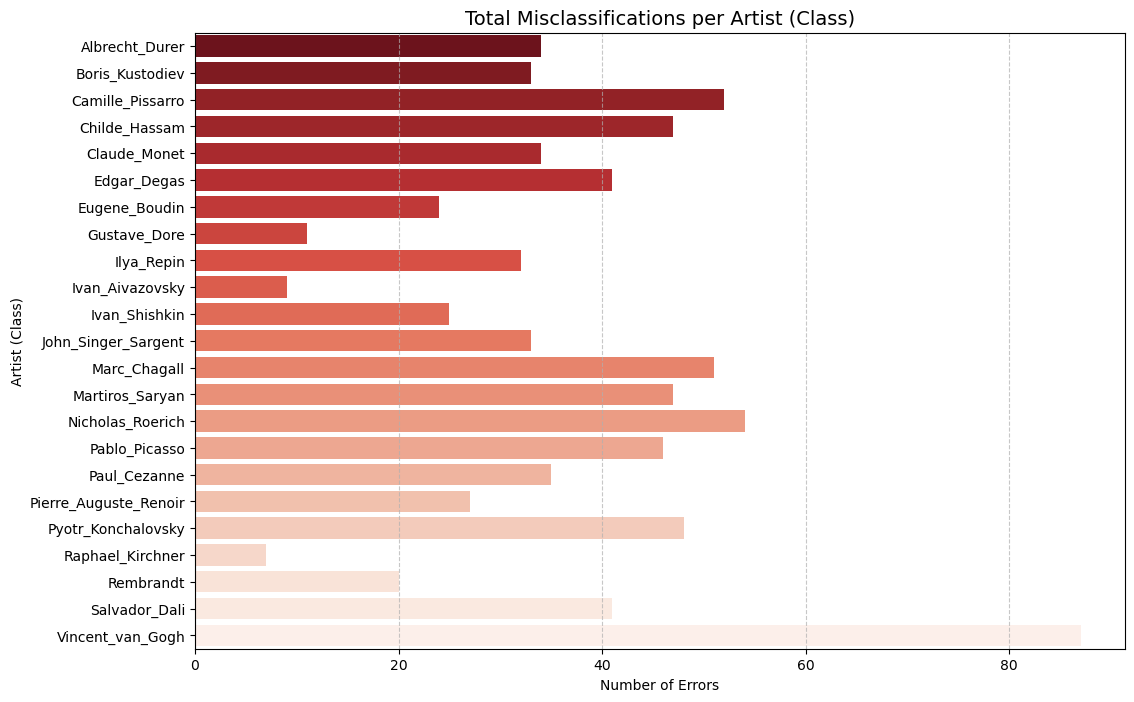

In [ ]:
# Calculate error counts
error_counts = []
for i in range(len(class_names)):
    error_counts.append(cm[i].sum() - cm[i, i]) #cm is the confusion matrix

# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=error_counts, y=class_names, palette='Reds_r')

plt.title('Total Misclassifications per Artist (Class)', fontsize=14)
plt.xlabel('Number of Errors')
plt.ylabel('Artist (Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your project folder
plt.savefig(FIGURES_DIR / 'errors_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_20376\420947982.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_df, x='Error %', y='Artists (Classes)', palette='magma')


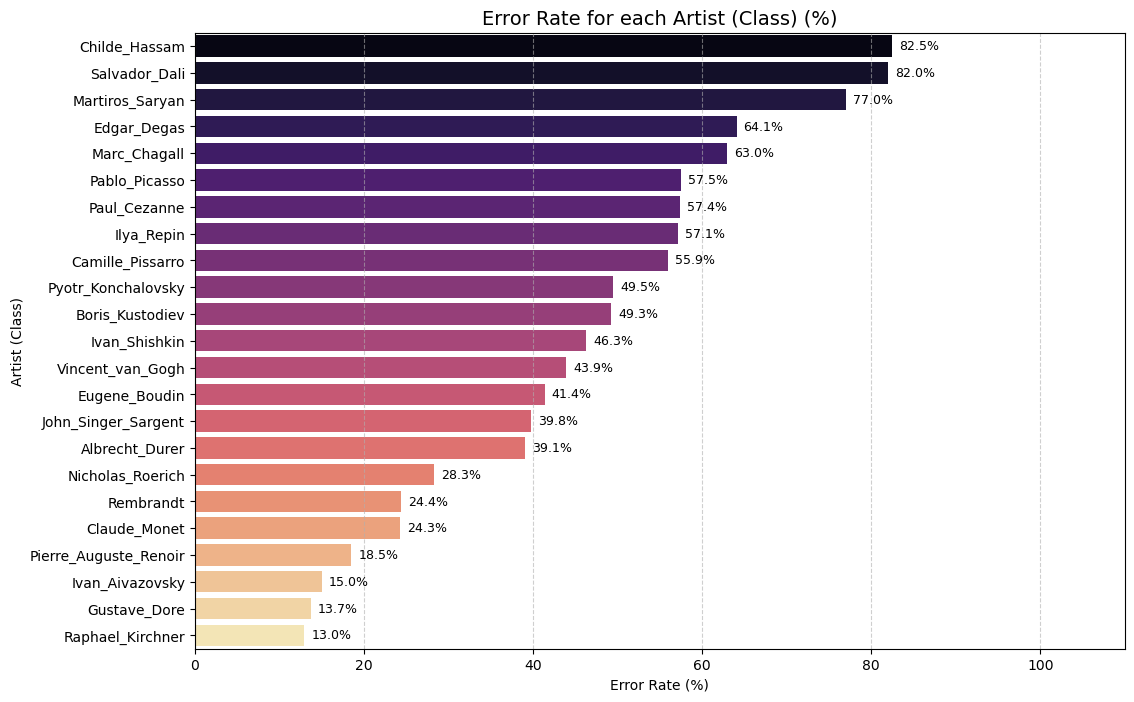

In [ ]:
# percentage of errors for each class

for i in range(len(class_names)):
    total_samples = cm[i].sum()
    if total_samples > 0:
        # (Total images - correct predictions / total images) * 100
        error_pct = (1 - (cm[i,i]) / total_samples) * 100
        per_class_error_pct.append(error_pct)
    else:
        per_class_error_pct.append(0)

# Save as DataFrame to ease the visualization

error_df = pd.DataFrame({
    'Artists (Class)': class_names,
    'Error %': per_class_error_pct
}).sort_values('Error %', ascending=False) # Order by the classes with the bigger % of error

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')

# To appear the % on the bars. 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9)

plt.title('Error Rate for each Artist (Class) (%)', fontsize=14)
plt.xlabel('Error Rate (%)')
plt.ylabel('Artist (Class)')
plt.xlim(0, 110) # text
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(FIGURES_DIR / 'error_percentage_by_class.png', dpi=150, bbox_inches='tight')
plt.show()